<a href="https://colab.research.google.com/github/mitshiabopm-bot/Bright-TV/blob/main/Retail_Sales_23032026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_excel("/retail_sales_dataset.csv.xlsx")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [ ]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df["Product Category"].unique()

array(['Beauty', 'Clothing', 'Electronics'], dtype=object)

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
995,False
996,False
997,False
998,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [ ]:
df["Age"].min()

18

In [ ]:
df["Age"].max()

64

In [ ]:
bins = [18, 30, 40, 50, 64]
labels = ['18-30', '31-40', '41-50', '51-64']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

display(df[['Age', 'Age Group']].head())

,Age,Age Group
0,34,31-40
1,26,18-30
2,50,41-50
3,37,31-40
4,30,18-30


In [ ]:
age_group_sales = df.groupby('Age Group')['Total Amount'].sum().reset_index()
display(age_group_sales)

/tmp/ipykernel_5650/132928284.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_sales = df.groupby('Age Group')['Total Amount'].sum().reset_index()


,Age Group,Total Amount
0,18-30,132945
1,31-40,95950
2,41-50,93795
3,51-64,133310


/tmp/ipykernel_5650/2660642833.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_age_group = (df.groupby('Age Group')['Total Amount'].sum().sort_values(ascending=False).head(4))


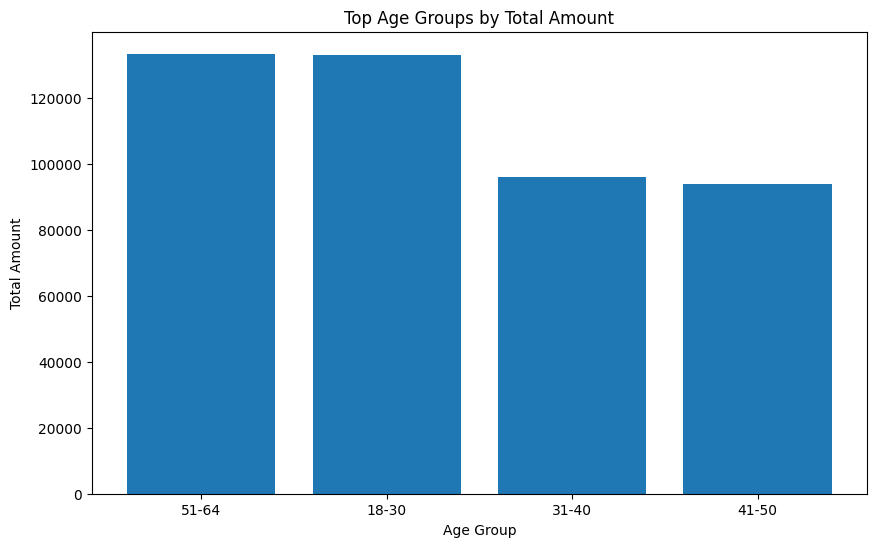

In [ ]:
top_age_group = (df.groupby('Age Group')['Total Amount'].sum().sort_values(ascending=False).head(4))
plt.figure(figsize=(10, 6))
plt.bar(top_age_group.index, top_age_group.values)
plt.xlabel('Age Group')
plt.ylabel('Total Amount')
plt.title('Top Age Groups by Total Amount')
plt.show()

In [ ]:
df.groupby("Gender")["Total Amount"].sum()

,Total Amount
Gender,
Female,232840
Male,223160


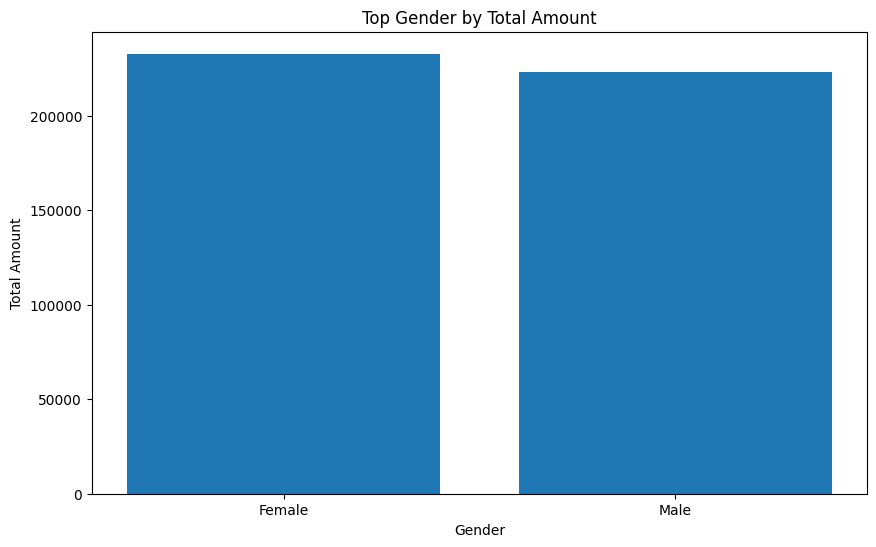

In [ ]:
top_Gender = (df.groupby('Gender')['Total Amount'].sum().sort_values(ascending=False).head(4))
plt.figure(figsize=(10, 6))
plt.bar(top_Gender.index, top_Gender.values)
plt.xlabel('Gender')
plt.ylabel('Total Amount')
plt.title('Top Gender by Total Amount')
plt.show()

In [ ]:
df.groupby("Product Category")["Total Amount"].sum()

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


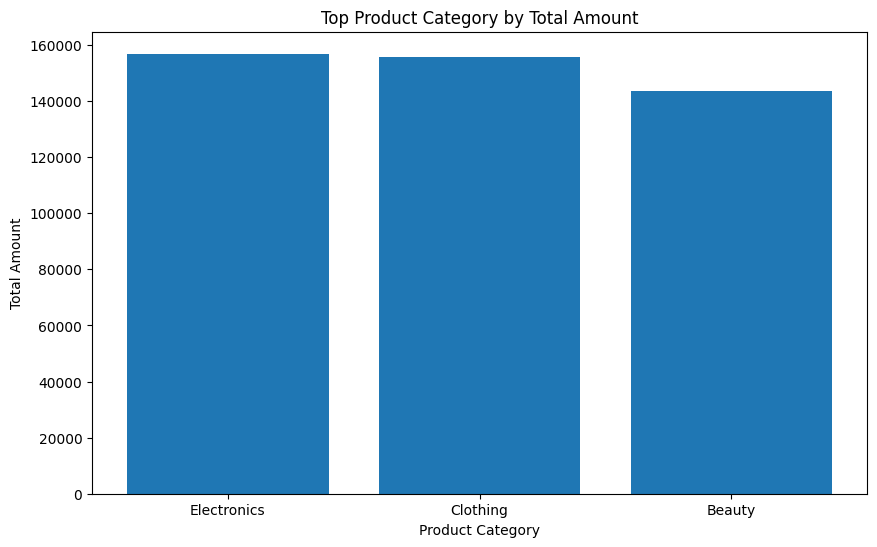

In [ ]:
top_product_category = (df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).head(4))
plt.figure(figsize=(10, 6))
plt.bar(top_product_category.index, top_product_category.values)
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.title('Top Product Category by Total Amount')
plt.show()